# Tutorial: Generating and Inspecting SFTs from GWOSC Data

Short Fourier Transforms (SFTs) are a fundamental data product in continuous-wave (CW) and other narrow-band gravitational-wave analyses. By dividing calibrated detector strain data into fixed-duration segments and Fourier transforming each segment, SFTs provide a compact and flexible time–frequency representation that is well suited for searches for long-lived, quasi-monochromatic signals, as well as for detailed spectral characterization of detector noise.

In this tutorial, we demonstrate an end-to-end workflow for producing and validating SFTs from publicly available gravitational-wave data. Starting from strain data distributed by the Gravitational Wave Open Science Center (GWOSC), we generate SFTs using the standard LALSuite tool `lalpulsar_MakeSFTs`. We then use the Python package `PyFstat` to read the resulting SFTs into NumPy arrays and perform a series of basic but essential sanity checks.

Specifically, this notebook covers:

- Downloading calibrated GWOSC frame data for a chosen detector and time interval
- Creating LAL-style cache files for use with `lalpulsar_MakeSFTs`
- Generating SFTs with controlled parameters (SFT duration, windowing, frequency band)
- Loading SFTs in Python using `pyfstat.utils.get_sft_as_arrays`
- Computing and plotting single-SFT spectra
- Estimating the noise power spectral density (PSD) using running-median methods
- Performing statistical sanity checks of whitened SFT power
- Constructing time–frequency spectrograms from SFT data

The goal is not to perform a full CW search, but rather to illustrate best practices for working with SFTs: understanding their normalization, validating their statistical properties, and visualizing their spectral content. These steps are essential prerequisites for many CW and narrow-band analyses, and the techniques shown here are directly applicable to more advanced pipelines.

This tutorial assumes basic familiarity with Fourier transforms and gravitational-wave data formats, but no prior experience with LALSuite or PyFstat is required.


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/andrew-l-miller/gwosc/blob/main/make_sfts/make_SFTs.ipynb)

In [ ]:
from pathlib import Path
import os
import sys
import requests
import argparse
import matplotlib.pyplot as plt
import numpy as np
import scipy
import glob
import shlex
import shutil
import subprocess
import re
import importlib ##importlib.reload(pacakge_name) to refresh
%matplotlib inline

In [ ]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if os.path.basename(os.getcwd()) == "make_sfts":
        print('things already downloaded')
    else:
        print("downloading codes and compiled code")
        !git clone https://github.com/andrew-l-miller/gwosc.git
        os.chdir('gwosc/make_sfts')


!wget -nc https://dcc.ligo.org/public/0192/T2400058/003/segsH1AnalysisReadyMinusVetoes_O4a_C00_g0f406df6.txt
!wget -nc https://dcc.ligo.org/public/0192/T2400058/003/segsL1AnalysisReadyMinusVetoes_O4a_C00_g0f406df6.txt



### Install environment to run make SFTs C code in

In [ ]:
if IN_COLAB:
    !curl -Ls https://micro.mamba.pm/api/micromamba/linux-64/latest | tar -xvj bin/micromamba
    !./bin/micromamba create -y -n igwn -c conda-forge lalpulsar

#### Check to see that lalpulsar_MakeSFTs (the function to create SFTs) is installed

In [ ]:
!./bin/micromamba run -n igwn which lalpulsar_MakeSFTs

### Import functions to download gravitational-wave strain data from GWOSC and to create SFTs

In [ ]:
sys.path.append(os.path.abspath("../create_sfdbs"))
from download_all_data_from_run import download_gwf
from make_ffl import *
from utils import make_cache_file, make_sfts

### Choose which observing run, interferometer, start/end time to analyze, which channel, which freq band

If you want to download data for the whole run, simply put `gps_start=gps_end=None`

In [ ]:
obs_run = 'O4a'
ifo = 'H1'
runn = obs_run+'_4KHZ_R1'
channel = ifo+':GWOSC-4KHZ_R1_STRAIN'
gwf_dir = './data/'+obs_run+'/'+ifo+'/'
gps_start = 1369185055
gps_end = gps_start+10*4096
start_freq = 10.0
band = 1600.0
outdir = "./sfts/"+obs_run+'/'+ifo+'/'

### Download the desired gravitational-wave frame (.gwf) files

In [ ]:
download_gwf(runn,ifo,gwf_dir,gps_start,gps_end)

### Make a list of GW frame files and save it as an .ffl file

In [ ]:
ffl_name = ifo+'_'+channel+'.ffl'
make_ffl(gwf_dir,ffl_name,absolute=True)

### Create the .cache file (a necessary input for making SFTs)

In [ ]:
cache_fname = ifo+'_'+obs_run+'.cache'
make_cache_file(ffl=ffl_name,ifo=ifo,channel_id=channel,cache_out=cache_fname)


### MAKE SFTs

In [ ]:
make_sfts(
    cache_file=cache_fname,
    gps_start_time=gps_start,
    gps_end_time=gps_end,
    sft_write_path=outdir,
    start_freq=start_freq,
    band=band,
    channel_name=channel
)


## Making sanity-check plots

### Compute spectrogram

In [ ]:
!pip install pyfstat
import pyfstat
from scipy.signal import medfilt

In [74]:
freqs, times, sft_data = pyfstat.utils.get_sft_as_arrays(outdir+'*.sft')

powers = np.abs(sft_data[ifo]).astype(np.float64) ** 2
Nfreqs,Nsft = powers.shape

psds = np.zeros((Nfreqs, Nsft))
median_width = 461   # must be odd ; larger --> median is taken over more freq bins

for i in range(Nsft):
    psds[:,i] = medfilt(powers[:,i], kernel_size=median_width) / np.log(2)

whitened_power = powers / psds



### Plot one of the spectra and the estimate of its amplitude spectral density (ASD)

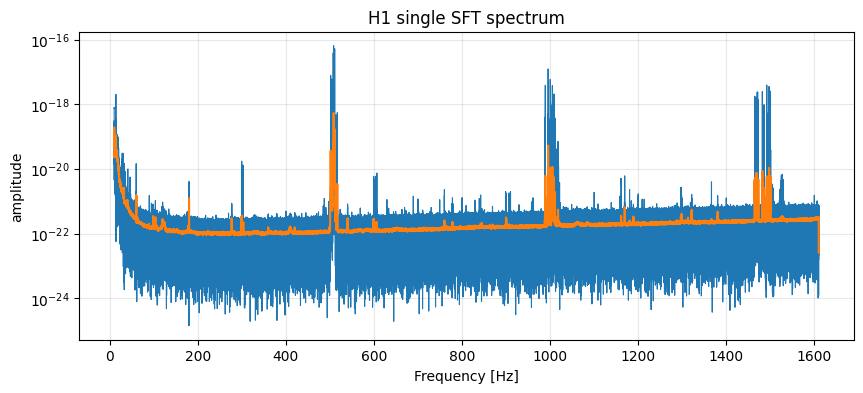

In [75]:
## Plot one spectrum
plt.figure(figsize=(10, 4))
plt.semilogy(freqs, np.sqrt(powers[:,0]), lw=0.8)
plt.semilogy(freqs, np.sqrt(psds[:,0]))
plt.xlabel("Frequency [Hz]")
plt.ylabel("amplitude")
plt.title(f"{ifo} single SFT spectrum")
plt.grid(True, alpha=0.3)

### Plot the distribution of the ratio of the spectra to the ASD estimate, to see that it is exponential

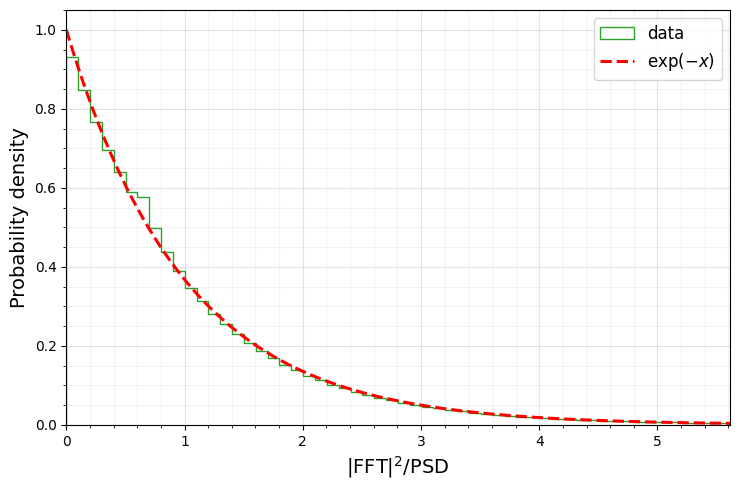

mean: 1.0075575234493712
std: 1.0617789513557054
median: 0.6931471805599453


In [76]:
xv = whitened_power[:,0]
xv = xv[xv < np.percentile(xv, 99.9)]

plt.figure(figsize=(7.5, 5))

# Histogram (linear space)
plt.hist(
    xv,
    bins=200,
    density=True,
    histtype='step',
    lw=2.0,
    color='tab:green',
    label='data'
)

# Theoretical exponential PDF (mean=1)
xx = np.linspace(0, np.percentile(xv, 99.9), 2000)  # just for drawing the curve nicely
plt.plot(
    xx,
    np.exp(-xx),
    'r--',
    lw=2.2,
    label=r'$\exp(-x)$'
)

plt.xlabel(r'$|{\rm FFT}|^2 / {\rm PSD}$', fontsize=14)
plt.ylabel('Probability density', fontsize=14)

plt.grid(True, which='major', alpha=0.35)
plt.grid(True, which='minor', alpha=0.15)
plt.minorticks_on()

# No tail clipping of the data, but you *do* want sane axes for visibility:
plt.xlim(0, np.percentile(xv, 99.5))
plt.ylim(bottom=0)

plt.legend(frameon=True, fontsize=12, loc='upper right')

plt.tight_layout()
plt.show()

print("mean:", np.mean(xv))
print("std:", np.std(xv))
print("median:", np.median(xv))

### Plot a spectrogram in a chosen 1-Hz band

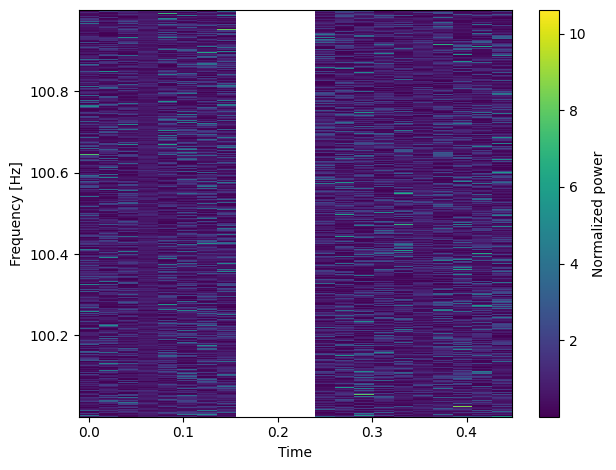

In [77]:
fmin = 100
fmax = 101
mask = (freqs > fmin) & (freqs < fmax)

plt.pcolormesh((times[ifo]-times[ifo][0])/86400, freqs[mask], whitened_power[mask,:], shading="auto")
plt.xlabel("Time")
plt.ylabel("Frequency [Hz]")
plt.colorbar(label="Normalized power")
plt.tight_layout()